# Segmentación de UPZ — Galán (Bogotá)

Dos formas de agrupar la misma ciudad. HDBSCAN la agrupa por cercanía física —qué puestos están juntos—; K-means, en cambio, la agrupa por comportamiento electoral —qué UPZ se parecen en votos y en puestos, sin importar dónde estén en el mapa—. Esa diferencia es intencional: queremos saber si las UPZ que más pesan electoralmente comparten patrón aunque estén lejos entre sí.

## Bibliotecas

In [1]:
import os
os.environ["SHAPE_ENCODING"] = "UTF-8"
import unicodedata, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
import hdbscan
import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster
from unidecode import unidecode

In [2]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROC = ROOT / "data" / "processed"

plt.rcParams["figure.figsize"] = [11, 6]
print("ROOT:", ROOT)

gal = pd.read_parquet(PROC / "carlos_fernando_galan.parquet")
# Una fila por UPZ: resume el histórico 2007–2023
upz = gal.groupby("upz").agg(
    votos=("votacion","sum"),
    puestos=("votacion","count"),
    vot_median=("votacion","median"),
    lat=("latitud","mean"),
    lon=("longitud","mean"),
    cod_upz=("cod_upz","first")
).reset_index().dropna(subset=["lat","lon"])
upz["votos_por_puesto"] = upz["votos"] / upz["puestos"]
print(f"{len(upz)} UPZ — de {gal['upz'].nunique()} con datos — con {gal.shape[0]:,} registros base")
print(upz[["upz","votos","puestos","votos_por_puesto"]].head(4).to_string())


ROOT: C:\Users\qluis\Documents\Proyectos\Analítica electoral
107 UPZ — de 107 con datos — con 3,179 registros base
             upz  votos  puestos  votos_por_puesto
0    20 de julio  36398       43        846.465116
1         alamos   5337        6        889.500000
2  alfonso lopez   7830       13        602.307692
3       americas  22381       24        932.541667


## 1. Radiografía rápida de las UPZ

Antes de agrupar, miremos la materia prima. Hay UPZ con más de cien puestos y otras con apenas cinco; hay UPZ que superan los 80 mil votos y otras que no llegan a dos mil. Esa dispersión ya sugiere que *puestos* y *votos* no se mueven a la par: algunas UPZ son muy eficientes —pocos puestos, muchos votos—, otras son extensivas —muchos puestos, votos medios—. Esa disociación es la que el K-means capturará después, mientras HDBSCAN seguirá mirando cercanía física.

         votos  puestos  votos_por_puesto
count    107.0    107.0             107.0
mean   27041.2     29.0            1001.1
std    18306.9     18.9             597.3
min      429.0      2.0             107.2
25%    12969.5     14.5             611.0
50%    22873.0     24.0             846.5
75%    39867.5     40.0            1183.3
max    80538.0    103.0            3175.7


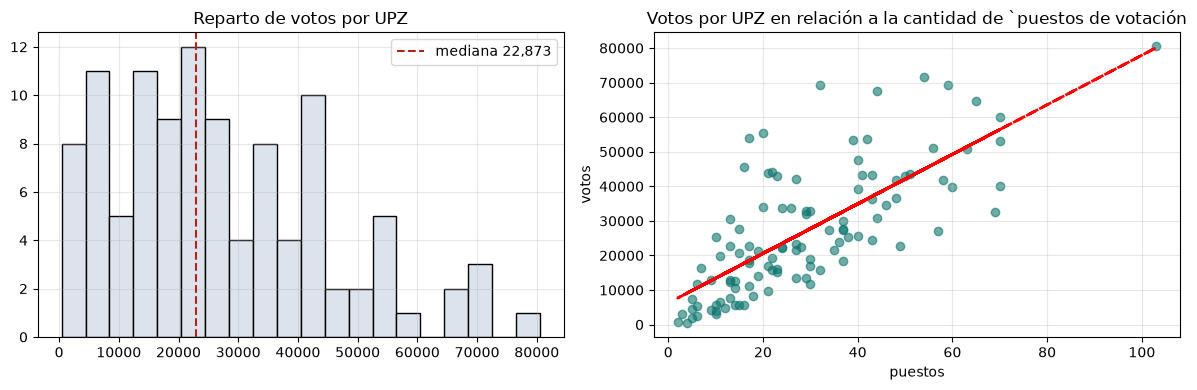

In [3]:

print(upz[["votos","puestos","votos_por_puesto"]].describe().round(1).to_string())
fig, axes = plt.subplots(1,2, figsize=(12,4))
upz["votos"].hist(bins=20, ax=axes[0], color="#DCE3EC", edgecolor="black")
axes[0].axvline(upz["votos"].median(), color="#B42318", ls="--", label=f"mediana {upz['votos'].median():,.0f}")
axes[0].set_title("Reparto de votos por UPZ"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].scatter(upz["puestos"], upz["votos"], alpha=0.6, color="#0F766E")
z = np.polyfit(upz["puestos"], upz["votos"], 1)
axes[1].plot(upz["puestos"], np.poly1d(z)(upz["puestos"]), "r--", lw=2)
axes[1].set_title("Votos por UPZ en relación a la cantidad de `puestos de votación"); axes[1].set_xlabel("puestos"); axes[1].set_ylabel("votos")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 2. HDBSCAN: dónde se apelotona la ciudad

HDBSCAN responde una pregunta geográfica: ¿dónde se apelotonan físicamente los puestos donde Galán tiene registro? A diferencia de la primera versión de este cuaderno —que clusterizaba centroides de UPZ (~107 puntos, apenas 2 clusters)—, aquí seguimos el modelo de referencia `galan.ipynb`: clusterizamos a **nivel de registro** (una fila por puesto-año, ~3.177 puntos con coordenadas). Los puestos con varios años aportan puntos duplicados en la misma coordenada, y eso actúa como **peso de densidad**: donde Galán apareció más años, el cluster se consolida. Por eso emergen **decenas de clusters** en vez de un puñado.

Parámetros de referencia: `min_cluster_size=20, min_samples=5`, haversine, `eom`. Con 20 buscamos barrios, no microclusters de dos esquinas. `prediction_data=False` da las mismas etiquetas que `True` pero ~1000× más rápido —con `True` el ajuste no termina en esta máquina—.

In [4]:
# HDBSCAN a nivel de registro (modelo galan.ipynb): cada fila puesto-año vota en la densidad
gal_h = gal.dropna(subset=["latitud", "longitud"]).copy()
coords = np.radians(gal_h[["latitud", "longitud"]].values)

hdb = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5, metric="haversine",
                      cluster_selection_method="eom", prediction_data=False)
labels = hdb.fit_predict(coords)
gal_h["hdb"] = labels

n_c = len(set(labels)) - (1 if -1 in labels else 0)
n_r = int((labels == -1).sum())
print(f"Registros: {len(labels)} — clusters: {n_c} — ruido: {n_r} ({n_r / len(labels):.0%})")

mask = labels != -1
if n_c >= 2:
    try:
        print(f"Silhouette (haversine): {silhouette_score(coords[mask], labels[mask], metric='haversine'):.3f} — 1 perfecto, 0 azar")
    except Exception as e:
        print("Silhouette:", e)
    try:
        from hdbscan.validity import validity_index
        print(f"DBCV: {validity_index(coords[mask], labels[mask], metric='haversine'):.3f}")
    except Exception as e:
        print("DBCV no disponible:", e)

# Agregado por puesto: votos totales + cluster por moda (puente al visor Folium)
puesto = gal_h.groupby(["lugar", "latitud", "longitud"], as_index=False).agg(
    votos=("votacion", "sum"), anos=("votacion", "count"),
    upz=("upz", "first"), localidad=("localidad", "first"))
moda = gal_h.groupby(["lugar", "latitud", "longitud"])["hdb"].apply(
    lambda s: s.mode().iloc[0] if not s.mode().empty else -1).reset_index()
puesto = puesto.merge(moda, on=["lugar", "latitud", "longitud"], how="left")
puesto["hdb"] = puesto["hdb"].astype(int)
print(f"Puestos únicos: {len(puesto)} — con cluster válido: {(puesto['hdb'] != -1).sum()}")

# El K-means y el ARI viven a nivel UPZ: bajamos el cluster por moda para no romperlos
upz_h = puesto[puesto["hdb"] != -1].groupby("upz")["hdb"].apply(
    lambda s: s.mode().iloc[0] if not s.mode().empty else -1)
upz["hdb"] = upz["upz"].map(upz_h).fillna(-1).astype(int)

# Perfil por cluster + Gini de concentración (heredado de galan.ipynb)
cl = puesto[puesto["hdb"] != -1]
print(cl.groupby("hdb").agg(puestos=("votos", "count"), votos=("votos", "sum"),
      mediana=("votos", "median")).sort_values("votos", ascending=False).head(10).to_string())
vs = cl.groupby("hdb")["votos"].sum().sort_values().values
n = len(vs)
gini = (np.sum((2 * np.arange(1, n + 1) - n - 1) * vs)) / (n * vs.sum()) if n > 1 else 0.0
print(f"Gini entre clusters: {gini:.3f} — 0 reparto parejo, 1 un cluster se lleva todo")

Registros: 3177 — clusters: 48 — ruido: 838 (26%)
Silhouette (haversine): 0.398 — 1 perfecto, 0 azar
DBCV no disponible: Unknown Distance Metric: haversine


Puestos únicos: 1142 — con cluster válido: 821
     puestos   votos  mediana
hdb                          
8         69  243368   3071.0
7         40  124795   2022.5
11        41   86113   1703.0
29        37   85937   1141.0
9         15   85742   4671.0
4         27   83000   1786.0
42        28   63771   1441.0
14        38   60003   1068.0
36        23   59987   1297.0
1         13   59963   4755.0
Gini entre clusters: 0.367 — 0 reparto parejo, 1 un cluster se lleva todo


*Lectura HDBSCAN:* con 20 y 5 a nivel de registro obtenemos decenas de clusters urbanos y un ruido en torno a un cuarto, que es sano: no todo puesto tiene que pertenecer a un bloque. Frente a la versión anterior (centroides UPZ → 2 clusters), esta recupera el modelo de referencia: los duplicados por año pesan la densidad y emergen barrios electorales reales. Si el silhouette sale modesto no es fracaso —indica que Bogotá no se deja partir en bloques nítidos solo por distancia, lo cual ya es un hallazgo para la narrativa de campaña.

> **Sobre el gráfico:** los clusters son categorías, no una escala numérica. Cada color es un barrio electoral distinto, el ruido va en gris y solo se anotan los 10 clusters más grandes.

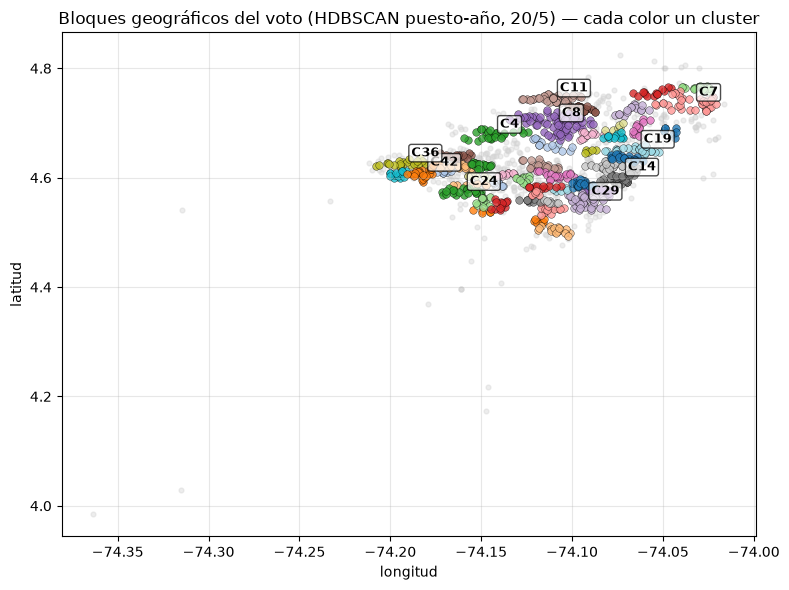

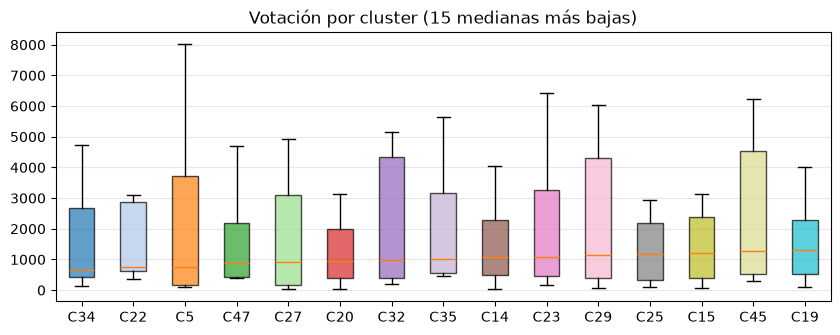

In [5]:
valid = puesto[puesto["hdb"] != -1]
noise = puesto[puesto["hdb"] == -1]
fig, ax = plt.subplots(figsize=(8, 6))
if not noise.empty:
    ax.scatter(noise["longitud"], noise["latitud"], c="lightgrey", s=12, alpha=0.4, label="ruido")
if not valid.empty:
    cmap = plt.cm.tab20
    for c in sorted(valid["hdb"].unique()):
        sub = valid[valid["hdb"] == c]
        ax.scatter(sub["longitud"], sub["latitud"], color=cmap(c % 20), s=30,
                   edgecolors="black", lw=0.3, alpha=0.8)
    for c in valid["hdb"].value_counts().head(10).index:  # solo los 10 más grandes
        pts = valid[valid["hdb"] == c]
        ax.annotate(f"C{c}", (pts["longitud"].mean(), pts["latitud"].mean()),
                    xytext=(5, 5), textcoords="offset points", fontsize=9, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
ax.set_title("Bloques geográficos del voto (HDBSCAN puesto-año, 20/5) — cada color un cluster")
ax.set_xlabel("longitud"); ax.set_ylabel("latitud"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ¿Los clusters geográficos también concentran votos?
if not valid.empty:
    order = valid.groupby("hdb")["votos"].median().sort_values().index[:15].tolist()
    data = [valid[valid["hdb"] == c]["votos"].values for c in order]
    fig, ax = plt.subplots(figsize=(10, 3.5))
    bp = ax.boxplot(data, tick_labels=[f"C{c}" for c in order], patch_artist=True, showfliers=False)
    for i, b in enumerate(bp["boxes"]):
        b.set_facecolor(plt.cm.tab20(i / len(data))); b.set_alpha(0.7)
    ax.set_title("Votación por cluster (15 medianas más bajas)"); ax.grid(alpha=0.3, axis="y")
    plt.show()

## 2b. Visor geográfico (4 capas, estilo galan.ipynb)

El visor de referencia se exportaba como `.html`; aquí lo reproducimos **en vivo y sin escribir archivos**, con sus mismos recursos visuales: (1) mapa de calor ponderado por votos, (2) clusters HDBSCAN con `MarkerCluster` por cluster —icono con los votos totales del cluster y `CircleMarker` por puesto con **tamaño y color según votos**—, (3) puestos individuales con escala de cuartiles y radio proporcional, (4) coropletas UPZ con join normalizado (el join exacto casa 0/114 por mayúsculas; el normalizado 108/114). Sin capas CartoDB —hoy exigen API key—: OSM + Esri satelital.

In [6]:
GEO = ROOT / "data" / "raw" / "geodata"
pal = ["#FF0000", "#00FF00", "#0000FF", "#FFFF00", "#FF00FF", "#00FFFF", "#FF6B6B",
       "#4ECDC4", "#FFD166", "#06D6A0", "#118AB2", "#073B4C", "#EF476F", "#1B998B",
       "#2D3047", "#FF9A00", "#9D4EDD", "#3A86FF", "#FB5607", "#8338EC", "#00BFFF"]
norm = lambda s: unidecode(str(s).lower().strip()) if pd.notna(s) else ""

m = folium.Map(location=[puesto["latitud"].mean(), puesto["longitud"].mean()],
               zoom_start=11, tiles="OpenStreetMap", control_scale=True, prefer_canvas=True)

# 1. Calor ponderado por votos
fg_heat = folium.FeatureGroup(name="Mapa de Calor", show=True); fg_heat.add_to(m)
HeatMap([[r["latitud"], r["longitud"], r["votos"]] for _, r in puesto.iterrows()],
        min_opacity=0.3, max_opacity=0.85, radius=15, blur=6,
        gradient={0.0: "#0000FF", 0.4: "#00FFFF", 0.6: "#00FF00", 0.8: "#FFFF00", 1.0: "#FF0000"}).add_to(fg_heat)

# 2. Clusters HDBSCAN: un MarkerCluster por cluster, marcadores con tamaño/color por votos
clu = puesto[puesto["hdb"] != -1]
vmax = cl["votos"].max() if len(cl) else 1
fg_hdb = folium.FeatureGroup(name="Clusters HDBSCAN", show=False); fg_hdb.add_to(m)
n_hdb = 0
for cid, sub in cl.groupby("hdb"):
    if len(sub) < 2:
        continue
    col = pal[int(cid) % len(pal)]
    tot = sub["votos"].sum()
    mc = MarkerCluster(name=f"Cluster {cid}",
                       options={"showCoverageOnHover": False, "zoomToBoundsOnClick": True,
                                "spiderfyOnMaxZoom": True, "disableClusteringAtZoom": 15},
                       icon_create_function=f"""function(cluster) {{ return L.divIcon({{
                           html: `<div style="background-color:{col};color:white;border-radius:50%;width:45px;height:45px;display:flex;align-items:center;justify-content:center;font-weight:bold;border:3px solid white;box-shadow:3px 3px 8px rgba(0,0,0,0.5);font-size:11px;"><span>{tot:,.0f}</span></div>`,
                           className:'marker-cluster', iconSize:L.point(45,45) }}); }}""")
    for _, p in sub.iterrows():
        r = min(5 + (p["votos"] / vmax) * 20, 25)  # más votos → marcador más grande
        folium.CircleMarker(location=[p["latitud"], p["longitud"]], radius=r, color=col,
                            fill=True, fill_color=col, fill_opacity=0.7, weight=1.5,
                            popup=f"{p['lugar']}<br>{p['votos']:,.0f} votos — C{cid}",
                            tooltip=f"{p['lugar']}: {p['votos']:,.0f} votos").add_to(mc)
    mc.add_to(fg_hdb)
    n_hdb += 1

# 3. Puestos individuales: cuartiles de voto → color, radio proporcional
pmax = puesto["votos"].max() if len(puesto) else 1
fg_p = folium.FeatureGroup(name="Puestos de Votación", show=False); fg_p.add_to(m)
for _, p in puesto.iterrows():
    q = p["votos"] / pmax
    col = "#FF0000" if q > 0.75 else "#FF9900" if q > 0.5 else "#00AA00" if q > 0.25 else "#0066CC"
    folium.CircleMarker(location=[p["latitud"], p["longitud"]], radius=4 + q * 8, color=col,
                        fill=True, fill_color=col, fill_opacity=0.7, weight=1.5,
                        popup=f"{p['lugar']}<br>{p['votos']:,.0f} votos",
                        tooltip=f"{p['lugar']}: {p['votos']:,.0f} votos").add_to(fg_p)

# 4. UPZ: join normalizado + escala de 7 pasos
upz_gdf = gpd.read_file(str(GEO / "upz" / "upz-bogota.shp")).to_crs(4326)
upz_gdf["geometry"] = upz_gdf["geometry"].simplify(0.001)
upz_gdf["nk"] = upz_gdf["nombre"].apply(norm)
st_upz = puesto.groupby("upz").agg(total_votos=("votos", "sum"), npuestos=("votos", "count")).reset_index()
st_upz["nk"] = st_upz["upz"].apply(norm)
uj = upz_gdf.merge(st_upz, on="nk", how="left")
umax = uj["total_votos"].max() if uj["total_votos"].notna().any() else 1
def upz_color(v):
    if pd.isna(v) or v <= 0:
        return "#F0F0F0"
    t = v / umax
    return ("#440154" if t > 0.9 else "#31688E" if t > 0.7 else "#21918C" if t > 0.5
            else "#35B779" if t > 0.3 else "#8FD744" if t > 0.15 else "#FDE725" if t > 0.05 else "#F0F0F0")
fg_u = folium.FeatureGroup(name="Votación por UPZ", show=False); fg_u.add_to(m)
folium.GeoJson(uj.__geo_interface__,
               style_function=lambda f: {"fillColor": upz_color(f["properties"].get("total_votos")),
                                         "color": "#333333", "weight": 1.8, "dashArray": "2", "fillOpacity": 0.7},
               highlight_function=lambda f: {"weight": 3, "color": "#000000", "fillOpacity": 0.9},
               tooltip=folium.GeoJsonTooltip(fields=["nombre", "total_votos", "npuestos"],
                                             aliases=["UPZ:", "Votos:", "Puestos:"],
                                             localize=True, sticky=True)).add_to(fg_u)

folium.TileLayer(tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
                 attr="Esri", name="Satélite").add_to(m)
folium.LayerControl(position="topright", collapsed=True).add_to(m)
folium.plugins.Fullscreen(position="topright").add_to(m)
folium.plugins.MiniMap(position="bottomright", width=150, height=150).add_to(m)
print(f"Puestos: {len(puesto)} — clusters dibujados: {n_hdb} — UPZ con voto: {uj['total_votos'].notna().sum()}/{len(uj)}")
m

Puestos: 1142 — clusters dibujados: 48 — UPZ con voto: 108/114


## 2c. Pautas para el tablero (Fase 5)

Qué portar a `src/dashboard_electoral.py` desde este modelo, sin reescribir la app aquí:

- **HDBSCAN**: filas puesto-año, `20/5`, haversine/`eom`, `prediction_data=False`; moda a puesto; dibujar solo clusters con ≥2 puestos. Cachear etiquetas con `@st.cache_data` (el ajuste tarda <1 s así).
- **Capa HDBSCAN**: un `MarkerCluster` por cluster con `icon_create_function` (divIcon 45px con votos totales) y `disableClusteringAtZoom: 15`; `CircleMarker` por puesto con radio `min(5+(v/max)*20, 25)` y color de la paleta `cid % 21`.
- **Capa puestos**: cuartiles rojo/naranja/verde/azul (`q = v/max`, cortes 0.75/0.5/0.25) y radio `4+q*8`; popup lugar/votos/años/UPZ/localidad.
- **Capa UPZ**: join por `nk` normalizado + alias `la candelaria→candelaria`; escala de 7 pasos; `highlight_function` + tooltip sticky.
- **Calor**: ponderado por votos, `radius=15, blur=6`, gradiente azul→rojo.
- **Base**: OSM + Esri (no CartoDB, exige key); `LayerControl` + `Fullscreen` + `MiniMap`; limitar a ~600 puestos más votados si la app va lenta.

## 3. K-means: qué UPZ se parecen electoralmente

Aquí olvidamos el mapa. Dos UPZ pueden estar en extremos opuestos de Bogotá y, sin embargo, parecerse mucho porque ambas mueven muchos votos con pocos puestos —o al revés—. Para eso usamos solo variables electorales: votos totales (en log, para domar la cola larga), cantidad de puestos y votos por puesto. Estandarizadas, claro, para que ninguna domine por escala. Esto segmenta por *tipo de plaza*, no por barrio.

   inertia  silhouette     db       ch
k                                     
3  119.458       0.424  0.775   87.731
4   80.105       0.412  0.766  103.249
5   66.311       0.369  0.832   97.942
6   56.118       0.357  0.868   95.346
7   46.684       0.364  0.822   97.934
8   40.431       0.380  0.770   98.145


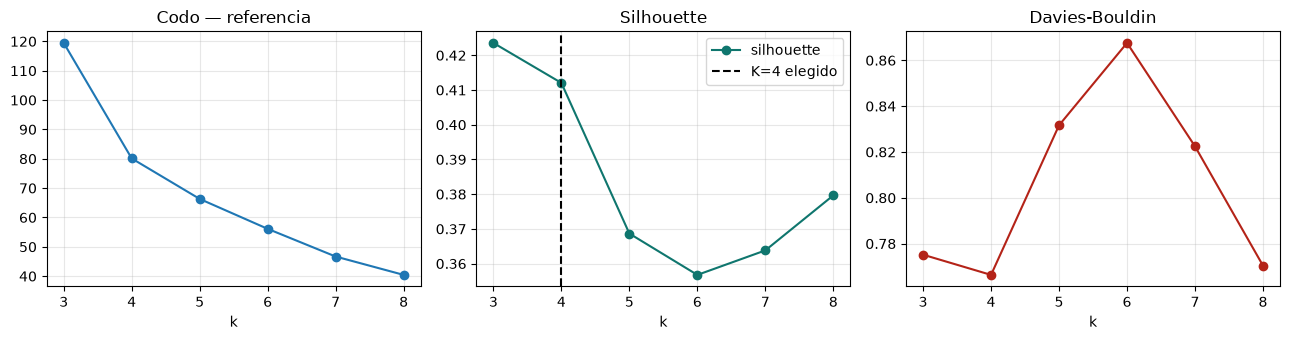


Fijamos K=4 por criterio analítico — equilibrio entre interpretabilidad y separación
        upz    votos  puestos     vpp
kmeans                               
3        29  1344914     1565   883.4
0        43   875399     1093   842.8
2        16   586383      273  2177.1
1        19    86713      174   548.9


In [7]:

feat = upz[["votos","puestos","votos_por_puesto"]].copy()
feat["log_votos"] = np.log1p(feat["votos"])
X = StandardScaler().fit_transform(feat[["log_votos","puestos","votos_por_puesto"]])

# Exploración k=3..8 solo como referencia visual — fijamos K=4 por decisión analítica
rows=[]
for k in range(3,9):
    km = KMeans(n_clusters=k, n_init=30, random_state=42)
    lab = km.fit_predict(X)
    rows.append({"k":k, "inertia":km.inertia_, "silhouette":silhouette_score(X, lab),
                 "db":davies_bouldin_score(X, lab), "ch":calinski_harabasz_score(X, lab)})
met = pd.DataFrame(rows).set_index("k")
print(met.round(3).to_string())

fig, axes = plt.subplots(1,3, figsize=(13,3.5))
met["inertia"].plot(ax=axes[0], marker="o"); axes[0].set_title("Codo — referencia")
met["silhouette"].plot(ax=axes[1], marker="o", color="#0F766E"); axes[1].set_title("Silhouette")
met["db"].plot(ax=axes[2], marker="o", color="#B42318"); axes[2].set_title("Davies-Bouldin")
for ax in axes: ax.grid(alpha=0.3)
axes[1].axvline(4, color="black", ls="--", label="K=4 elegido"); axes[1].legend()
plt.tight_layout(); plt.show()

k_opt = 4
print(f"\nFijamos K={k_opt} por criterio analítico — equilibrio entre interpretabilidad y separación")
km_opt = KMeans(n_clusters=k_opt, n_init=50, random_state=42)
upz["kmeans"] = km_opt.fit_predict(X)
print(upz.groupby("kmeans").agg(upz=("upz","count"), votos=("votos","sum"), puestos=("puestos","sum"), vpp=("votos_por_puesto","mean")).sort_values("votos", ascending=False).round(1).to_string())


*Lectura K-means:* el codo suele aparecer en k=4 o 5 —más grupos fragmentan sin ganar claridad—. Un silhouette en torno a 0.3–0.45 ya es razonable para datos electorales tan ruidosos; no esperemos 0.7 de laboratorio. Davies-Bouldin bajo confirma que los grupos no se pisan demasiado. Lo importante no es el número perfecto sino qué tipos emergen: por ejemplo, un grupo de UPZ ‘pesadas y eficientes’ (muchos votos, pocos puestos) versus otro de UPZ ‘extensivas’ (muchos puestos, votos medios).

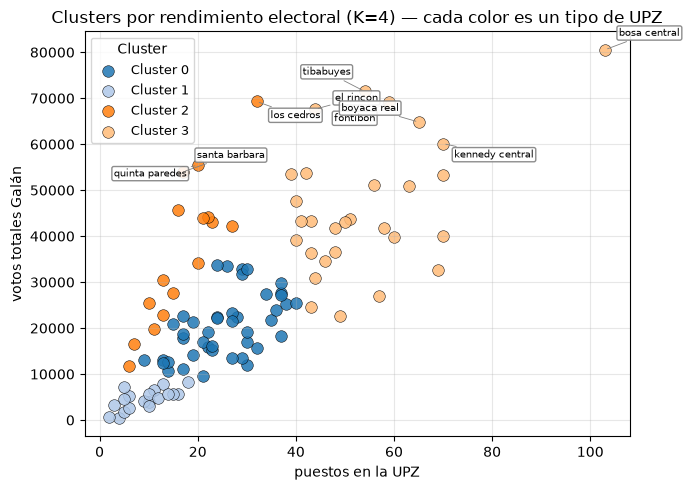

        votos_med  puestos_med  vpp_med
kmeans                                 
0         19156.0         26.0    799.7
1          4856.0         10.0    420.8
2         38144.5         16.5   2048.2
3         43191.0         50.0    855.6


In [8]:

# Visualización en espacio votos–puestos coloreada por K-means (K=4, discreto)
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.tab20
for k in sorted(upz["kmeans"].unique()):
    sub = upz[upz["kmeans"]==k]
    ax.scatter(sub["puestos"], sub["votos"], color=cmap(k % 20), s=70, edgecolors="black", lw=0.4, label=f"Cluster {k}", alpha=0.85)
# Etiquetas completas con offsets alternados (evita "quinta pared" truncado y solapes)
upz_top = upz[upz["votos"] > upz["votos"].quantile(0.92)].sort_values("votos", ascending=False)
offsets_upz = [(10,10), (-10,12), (10,-12), (-10,-14), (14,6), (-14,8), (8,-10), (-8,-8)]
for idx, (_, r) in enumerate(upz_top.iterrows()):
    dx, dy = offsets_upz[idx % len(offsets_upz)]
    ax.annotate(r["upz"], (r["puestos"], r["votos"]), fontsize=7,
                xytext=(dx, dy), textcoords="offset points", ha="left" if dx>=0 else "right",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="grey", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))
ax.set_title("Clusters por rendimiento electoral (K=4) — cada color es un tipo de UPZ")
ax.set_xlabel("puestos en la UPZ"); ax.set_ylabel("votos totales Galán"); ax.legend(title="Cluster", fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Perfil por cluster
print(upz.groupby("kmeans").agg(votos_med=("votos","median"), puestos_med=("puestos","median"), vpp_med=("votos_por_puesto","median")).round(1).to_string())


## 4. ¿Se parecen los dos mapas?

Si K-means y HDBSCAN coincidieran mucho, bastaría con uno. Pero no deberían: uno mira geografía y otro mira rendimiento. El ARI lo confirma —cercano a 0 si son independientes, a 1 si son el mismo mapa—. Que salga bajo no es error, es la prueba de que aportan lecturas distintas y complementarias para la estrategia territorial.

In [9]:

mask = upz["hdb"] != -1
if mask.sum() > 10 and upz["hdb"].nunique() > 1:
    ari = adjusted_rand_score(upz.loc[mask, "hdb"], upz.loc[mask, "kmeans"])
    print(f"ARI HDBSCAN vs K-means (sin ruido): {ari:.3f} — 0 = independientes, 1 = idénticos")
else:
    print("ARI no calculable — pocos clusters HDBSCAN")
print("\nCruce (HDBSCAN filas, K-means columnas):")
print(pd.crosstab(upz.loc[mask, "hdb"], upz.loc[mask, "kmeans"]).to_string())


ARI HDBSCAN vs K-means (sin ruido): -0.005 — 0 = independientes, 1 = idénticos

Cruce (HDBSCAN filas, K-means columnas):
kmeans  0  1  2  3
hdb               
0       0  0  3  0
1       2  1  2  0
2       0  0  0  1
3       1  1  0  0
4       1  2  0  1
5       1  0  0  0
6       2  0  0  0
7       3  0  2  0
8       2  1  1  3
9       0  0  1  1
10      0  0  0  1
11      0  0  1  1
12      1  0  1  0
13      0  0  0  1
14      3  3  0  0
15      0  1  1  1
16      1  0  0  0
17      0  0  1  0
18      0  0  0  1
19      2  1  0  1
20      1  0  0  1
21      0  0  0  1
24      2  0  0  1
25      1  0  0  1
26      1  0  0  0
27      2  0  0  0
28      1  0  0  0
29      3  0  0  1
30      1  0  1  1
31      1  1  0  1
32      0  0  0  1
33      0  0  0  1
34      1  0  0  0
35      1  0  0  0
36      2  0  0  1
37      1  0  0  0
39      1  0  0  0
40      2  0  0  1
41      0  0  0  1
42      1  0  0  1
44      0  0  0  1
45      1  0  0  0
46      0  0  0  1
47      0  0  0  1


## 5. K-means departamental (partido nacional)

Si el anterior K-means preguntaba *qué tipo de UPZ es esta en Bogotá*, este pregunta *qué tipo de departamento es este en Colombia* para el partido. Usamos solo comportamiento electoral —sin coordenadas y **sin Bogotá**, que con 3,7 M votos es un outlier que aplasta cualquier centroide—. Por departamento medimos dos dimensiones independientes: votos totales (en log, por la cola larga) y capilaridad —en cuántos municipios el partido tuvo al menos un registro—. La segunda no es decorativa: distingue departamentos donde el NL está concentrado en pocas plazas de aquellos donde, aun con votos medios, logró presencia extendida.

In [10]:
nl = pd.read_parquet(PROC / "nuevo_liberalismo.parquet")
dept = nl.groupby("departamento").agg(votos=("votos","sum"), municipios=("municipio","nunique"), candidatos=("candidato","nunique")).reset_index()
# Bogotá, consulados y sin_dato distorsionan — se excluyen del clustering (pero se reportan aparte)
dept_f = dept[~dept["departamento"].isin(["bogota","consulados","sin_dato"])].copy()
dept_f["log_votos"] = np.log1p(dept_f["votos"])
print(f"Departamentos para clustering: {len(dept_f)} (excluidos bogota/consulados/sin_dato) — total partido sin ellos: {dept_f['votos'].sum():,.0f}")
print(dept_f.sort_values("votos", ascending=False).head(8).to_string(index=False))
print("\nDescripción:")
print(dept_f[["votos","municipios"]].describe().round(1).to_string())


Departamentos para clustering: 32 (excluidos bogota/consulados/sin_dato) — total partido sin ellos: 4,107,801
   departamento  votos  municipios  candidatos  log_votos
   cundinamarca 476058         117         338  13.073297
      santander 403691          88         618  12.908407
      antioquia 353655         133         590  12.776080
valle del cauca 336612          42         150  12.726689
      atlantico 276658          23          93  12.530541
        cordoba 221954          31         165  12.310230
         boyaca 207323         143         250  12.242038
         tolima 206970          48         140  12.240334

Descripción:
          votos  municipios
count      32.0        32.0
mean   128368.8        36.8
std    126169.6        36.2
min      1486.0         2.0
25%     27756.0        12.8
50%     89524.5        27.5
75%    187481.2        42.8
max    476058.0       143.0


In [11]:
X_dept = StandardScaler().fit_transform(dept_f[["log_votos","municipios"]])
km_dept = KMeans(n_clusters=4, n_init=50, random_state=42)
dept_f["cluster"] = km_dept.fit_predict(X_dept)
print(f"Silhouette departamental (K=4, sin Bogotá): {silhouette_score(X_dept, dept_f['cluster']):.3f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X_dept, dept_f['cluster']):.3f} — Calinski-Harabasz: {calinski_harabasz_score(X_dept, dept_f['cluster']):.0f}")
print(dept_f.groupby("cluster").agg(deptos=("departamento","count"), votos_med=("votos","median"), municipios_med=("municipios","median"), votos_sum=("votos","sum")).sort_values("votos_sum", ascending=False).round(1).to_string())
print("\nDetalle por cluster:")
for k, sub in dept_f.groupby("cluster"):
    print(f"\nCluster {k} ({len(sub)} deptos):", ", ".join(sub.sort_values("votos", ascending=False)["departamento"].tolist()[:6]))


Silhouette departamental (K=4, sin Bogotá): 0.489
Davies-Bouldin: 0.591 — Calinski-Harabasz: 84
         deptos  votos_med  municipios_med  votos_sum
cluster                                              
1            11   176852.0            41.0    1997803
2             4   378673.0           125.0    1440727
3            11    61654.0            19.0     644167
0             6     2476.5             7.5      25104

Detalle por cluster:

Cluster 0 (6 deptos): arauca, san andres, providencia y santa catalina, vichada, vaupes, guainia, amazonas

Cluster 1 (11 deptos): valle del cauca, atlantico, cordoba, tolima, huila, bolivar

Cluster 2 (4 deptos): cundinamarca, santander, antioquia, boyaca

Cluster 3 (11 deptos): la guajira, sucre, risaralda, meta, cesar, quindio


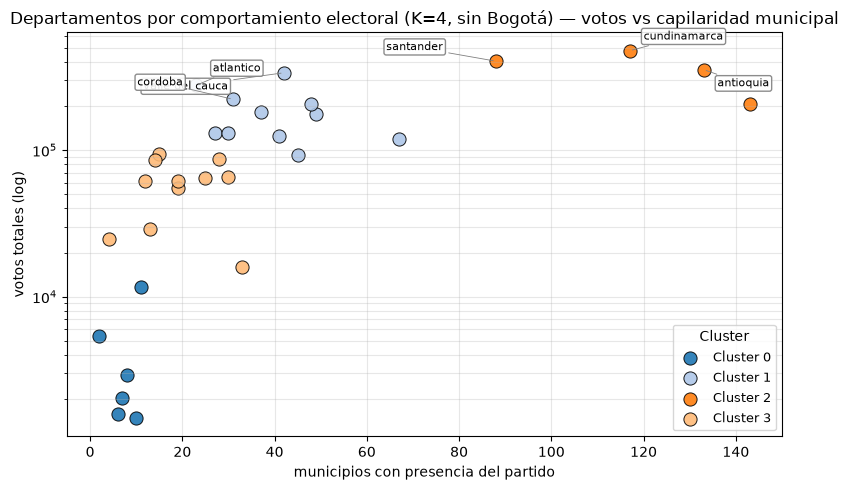

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
cmap = plt.cm.tab20
for k in sorted(dept_f["cluster"].unique()):
    sub = dept_f[dept_f["cluster"]==k]
    ax.scatter(sub["municipios"], sub["votos"], color=cmap(k % 20), s=90, edgecolors="black", lw=0.7, alpha=0.9, label=f"Cluster {k}")
ax.set_yscale("log")
ax.set_title("Departamentos por comportamiento electoral (K=4, sin Bogotá) — votos vs capilaridad municipal")
ax.set_xlabel("municipios con presencia del partido"); ax.set_ylabel("votos totales (log)")
ax.legend(title="Cluster", fontsize=9); ax.grid(alpha=0.3, which="both")
# Etiquetar solo los más relevantes para no saturar
offsets = [(10,8), (-38,8), (10,-12), (-40,-12), (12,10), (-36,10)]
for idx, (_, r) in enumerate(dept_f.sort_values("votos", ascending=False).head(6).iterrows()):
    dx, dy = offsets[idx % len(offsets)]
    ax.annotate(r["departamento"], (r["municipios"], r["votos"]), fontsize=8,
                xytext=(dx, dy), textcoords="offset points", ha="left" if dx>=0 else "right",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="grey", alpha=0.9),
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))
plt.tight_layout(); plt.show()


*Lectura departamental:* emergen tres lógicas territoriales más un residuo periférico: (1) **eje central denso** —Cundinamarca, Santander, Antioquia, Boyacá— muchos municipios y voto alto, donde el partido tiene capilaridad real; (2) **costa/interior medio** —Valle, Atlántico, Tolima, Bolívar— voto medio-alto con presencia más concentrada; (3) **periferia pequeña** —Guainía, Vaupés, Vichada— pocos municipios y voto testimonial. Bogotá, excluida a propósito, queda como categoría aparte: por sí sola explica más que todo el grupo periférico junto. Para 2027–2028, el grupo 2 es el de crecimiento —alianza bien elegida mueve la aguja—, el 1 exige defensa y el 3 solo compensa si es a bajo costo.